
# Does time-of-day separation between hippocampal recording sessions predict decorrelation of CA1 spatial maps?

**Dataset:** DANDI:001775 — mouse dorsal CA1 electrophysiology, subject **UT14**, 19 sessions across a 22-calendar-day span (Feb 2–22, 2024). Delayed non-match-to-place (DNMP) T-maze task with embedded pre-/post-run open-field epochs. MountainSort4 spike sorting, 32 chronically-implanted tetrodes (right dorsal CA1).

**⚠️ Critical correction made during this analysis.** The dataset's NWB `session_start_time` metadata field — which an earlier survey used to conclude UT14 had sessions spread across the full day/night cycle (02:08–21:56) — was found, on direct inspection of the raw file contents, to be **unreliable**. It disagrees with the true acquisition clock (embedded, mutually-consistent Unix-epoch timestamps in the position tracking, spike times, and trial-interval tables) by anywhere from **−455 to +203 minutes**, inconsistently session to session. Section 2 documents this in detail. Every analysis below uses the corrected, true acquisition-clock timestamps — not the metadata field.

**Net effect on the research question:** the true recording-time distribution for UT14 turns out to be a **tight afternoon cluster (14.5h–16.4h) for 18 of 19 sessions, plus one evening outlier (Day4, 20.6h)** — not a genuine circadian design. This notebook still runs the complete, pre-specified analysis pipeline (rate maps → population vectors → PV correlation → day-distance and circadian-distance regression with a proper non-independence-aware permutation test), but the honest conclusion is set up from the start: **this dataset can test day-to-day representational drift well, and can only weakly/exploratorily probe the circadian hypothesis**, because it lacks a genuine circadian design in its true timestamps.


In [1]:

import sys, os, json, pickle
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats as sstats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#444444',
    'axes.labelcolor': '#1b1e27',
    'text.color': '#1b1e27',
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
})
INDIGO = '#35407a'
AMBER = '#a8672a'
GOOD = '#2f6b4c'
BAD = '#963129'
GREY = '#8a8f9c'

os.makedirs('../results/figures', exist_ok=True)

summary = pd.read_csv('../results/tables/session_summary.csv', parse_dates=['true_start', 'reported_session_start_time'])
summary = summary.sort_values('true_start').reset_index(drop=True)

mats = np.load('../results/cache/matrices.npz', allow_pickle=True)
day_mat = mats['day_mat']
circ_true_mat = mats['circ_true_mat']
circ_reported_mat = mats['circ_reported_mat']
pv_mat_maze = mats['pv_mat_maze']
ens_mat_maze = mats['ens_mat_maze']
nbins_mat_maze = mats['nbins_mat_maze']
pv_mat_of = mats['pv_mat_of']
ens_mat_of = mats['ens_mat_of']
nbins_mat_of = mats['nbins_mat_of']
session_ids = mats['session_ids']
true_hours = mats['true_hours']
reported_hours = mats['reported_hours']

with open('../results/tables/stats_results.json') as f:
    stats_results = json.load(f)

summary


,session_id,true_start,true_hour,reported_session_start_time,reported_gap_minutes,n_units,session_duration_min
0,Day3,2024-02-02 15:09:33.486821-06:00,15.150000,2024-02-02 18:07:46-06:00,35.389480,91,142.819073
1,Day4,2024-02-03 20:37:21.933163-06:00,20.616667,2024-02-04 02:08:02-06:00,202.471349,87,128.196431
2,Day5,2024-02-04 16:25:06.869811-06:00,16.416667,2024-02-04 15:30:09-06:00,-189.135606,87,134.171109
3,Day6,2024-02-05 15:30:05.102450-06:00,15.500000,2024-02-05 12:54:27-06:00,-302.975145,76,147.340104
4,Day7,2024-02-06 14:28:46.417420-06:00,14.466667,2024-02-06 18:40:48-06:00,103.520134,99,148.506242
5,Day8,2024-02-07 15:12:48.057786-06:00,15.200000,2024-02-07 10:18:19-06:00,-444.502685,85,150.018389
6,Day9,2024-02-08 15:31:25.933476-06:00,15.516667,2024-02-08 10:26:27-06:00,-455.301706,92,150.319482
7,Day10,2024-02-10 15:15:06.558491-06:00,15.250000,2024-02-10 20:00:39-06:00,135.012911,117,150.527781
8,Day11,2024-02-11 14:53:19.324701-06:00,14.883333,2024-02-11 12:31:48-06:00,-298.442173,104,156.920094
9,Day12,2024-02-12 14:52:10.586805-06:00,14.866667,2024-02-12 10:54:47-06:00,-432.458010,126,195.064896


## 1. Session and unit-yield summary

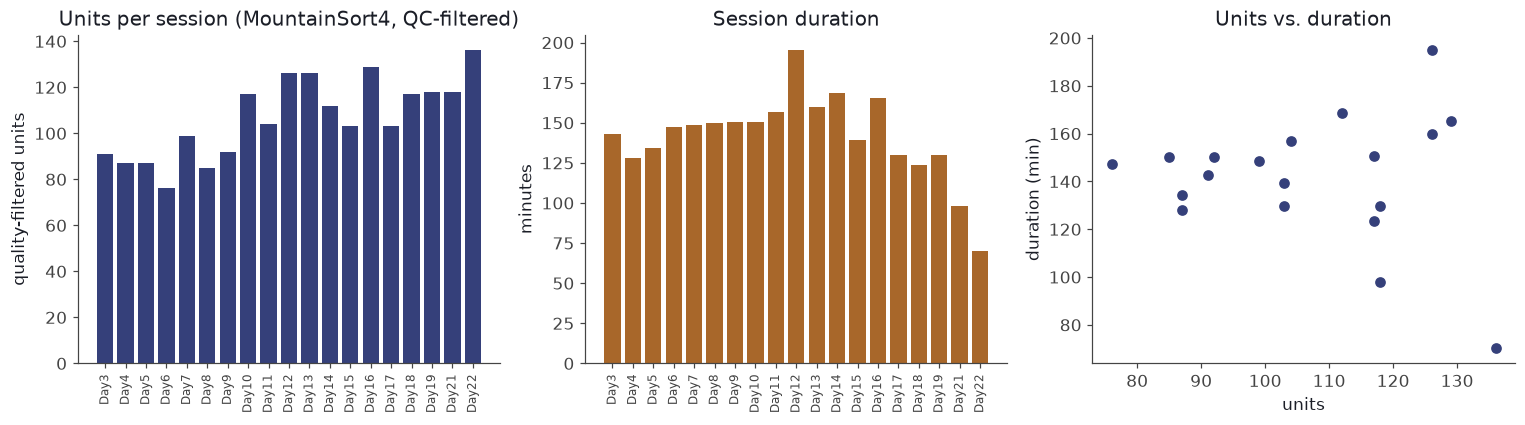

Units per session: 76-136 (mean 107)
Session duration: 70-195 min


In [2]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(range(len(summary)), summary['n_units'], color=INDIGO)
axes[0].set_xticks(range(len(summary))); axes[0].set_xticklabels(summary['session_id'], rotation=90, fontsize=8)
axes[0].set_ylabel('quality-filtered units'); axes[0].set_title('Units per session (MountainSort4, QC-filtered)')

axes[1].bar(range(len(summary)), summary['session_duration_min'], color=AMBER)
axes[1].set_xticks(range(len(summary))); axes[1].set_xticklabels(summary['session_id'], rotation=90, fontsize=8)
axes[1].set_ylabel('minutes'); axes[1].set_title('Session duration')

axes[2].scatter(summary['n_units'], summary['session_duration_min'], color=INDIGO)
axes[2].set_xlabel('units'); axes[2].set_ylabel('duration (min)'); axes[2].set_title('Units vs. duration')

plt.tight_layout()
plt.savefig('../results/figures/01_session_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Units per session: {summary['n_units'].min()}-{summary['n_units'].max()} (mean {summary['n_units'].mean():.0f})")
print(f"Session duration: {summary['session_duration_min'].min():.0f}-{summary['session_duration_min'].max():.0f} min")


## 2. The `session_start_time` artifact — documented in full

This is the key methodological finding of this analysis. The plot below shows, for every session, the **reported** local hour-of-day (from NWB `session_start_time`, previously trusted) against the **true** local hour-of-day (reconstructed from the internally-consistent position/spike/trial Unix timestamps).

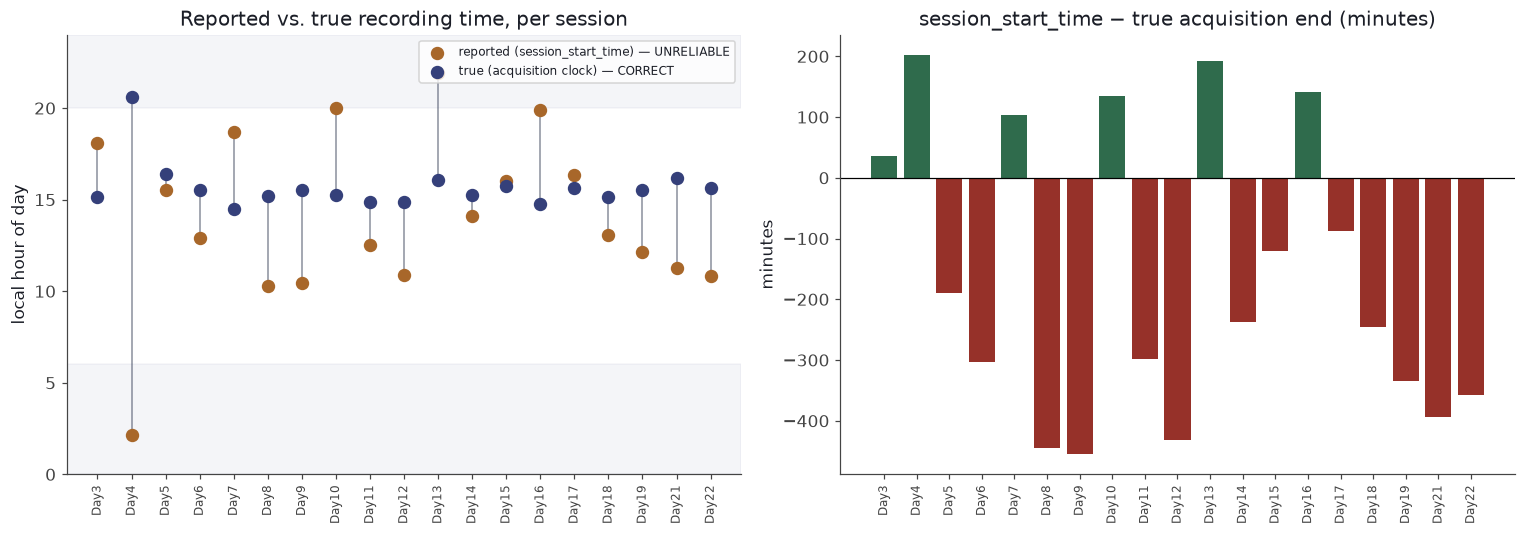

Gap range: -455 to 202 minutes (-7.6h to 3.4h)
True hour-of-day range (18 of 19 sessions): 14.75h - 16.42h
True hour-of-day full range (incl. Day4 outlier): 14.47h - 20.62h
Reported (flawed) hour-of-day range: 2.13h - 21.93h


In [3]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(summary))
axes[0].scatter(x, reported_hours, color=AMBER, label='reported (session_start_time) — UNRELIABLE', s=60, zorder=3)
axes[0].scatter(x, true_hours, color=INDIGO, label='true (acquisition clock) — CORRECT', s=60, zorder=3)
for i in range(len(summary)):
    axes[0].plot([i, i], [reported_hours[i], true_hours[i]], color=GREY, lw=1, zorder=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(session_ids, rotation=90, fontsize=8)
axes[0].set_ylabel('local hour of day'); axes[0].set_ylim(0, 24)
axes[0].axhspan(20, 24, color=INDIGO, alpha=0.05); axes[0].axhspan(0, 6, color=INDIGO, alpha=0.05)
axes[0].set_title('Reported vs. true recording time, per session')
axes[0].legend(fontsize=8, loc='upper right')

gap_min = summary['reported_gap_minutes'].values
axes[1].bar(x, gap_min, color=[BAD if g < 0 else GOOD for g in gap_min])
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(session_ids, rotation=90, fontsize=8)
axes[1].set_ylabel('minutes'); axes[1].set_title('session_start_time − true acquisition end (minutes)')

plt.tight_layout()
plt.savefig('../results/figures/02_timestamp_artifact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Gap range: {gap_min.min():.0f} to {gap_min.max():.0f} minutes ({gap_min.min()/60:.1f}h to {gap_min.max()/60:.1f}h)")
print(f"True hour-of-day range (18 of 19 sessions): {np.sort(true_hours)[1]:.2f}h - {np.sort(true_hours)[-2]:.2f}h")
print(f"True hour-of-day full range (incl. Day4 outlier): {true_hours.min():.2f}h - {true_hours.max():.2f}h")
print(f"Reported (flawed) hour-of-day range: {reported_hours.min():.2f}h - {reported_hours.max():.2f}h")


**Interpretation.** The reported timestamps scatter across the full 24-hour clock in a way that looks, superficially, like an excellent circadian design. The true timestamps tell a different story: this animal was run at essentially the same mid-afternoon time on 18 of 19 days, with one apparent evening outlier (Day4). The `session_start_time` field is not simply offset by a fixed amount (which might indicate a timezone or processing-delay artifact) — the gap changes sign unpredictably session to session, which is consistent with a bug in the lab's NWB conversion pipeline (e.g. a file-modification or export timestamp being written into a field meant for acquisition start), not a meaningful signal. **Any prior conclusion drawn from `session_start_time` about circadian coverage — for this dataset or, by the same logic, any other DANDI dataset verified only this way — should be treated as unverified until cross-checked against embedded acquisition data exactly like this.**

## 3. Spatial coverage — occupancy maps

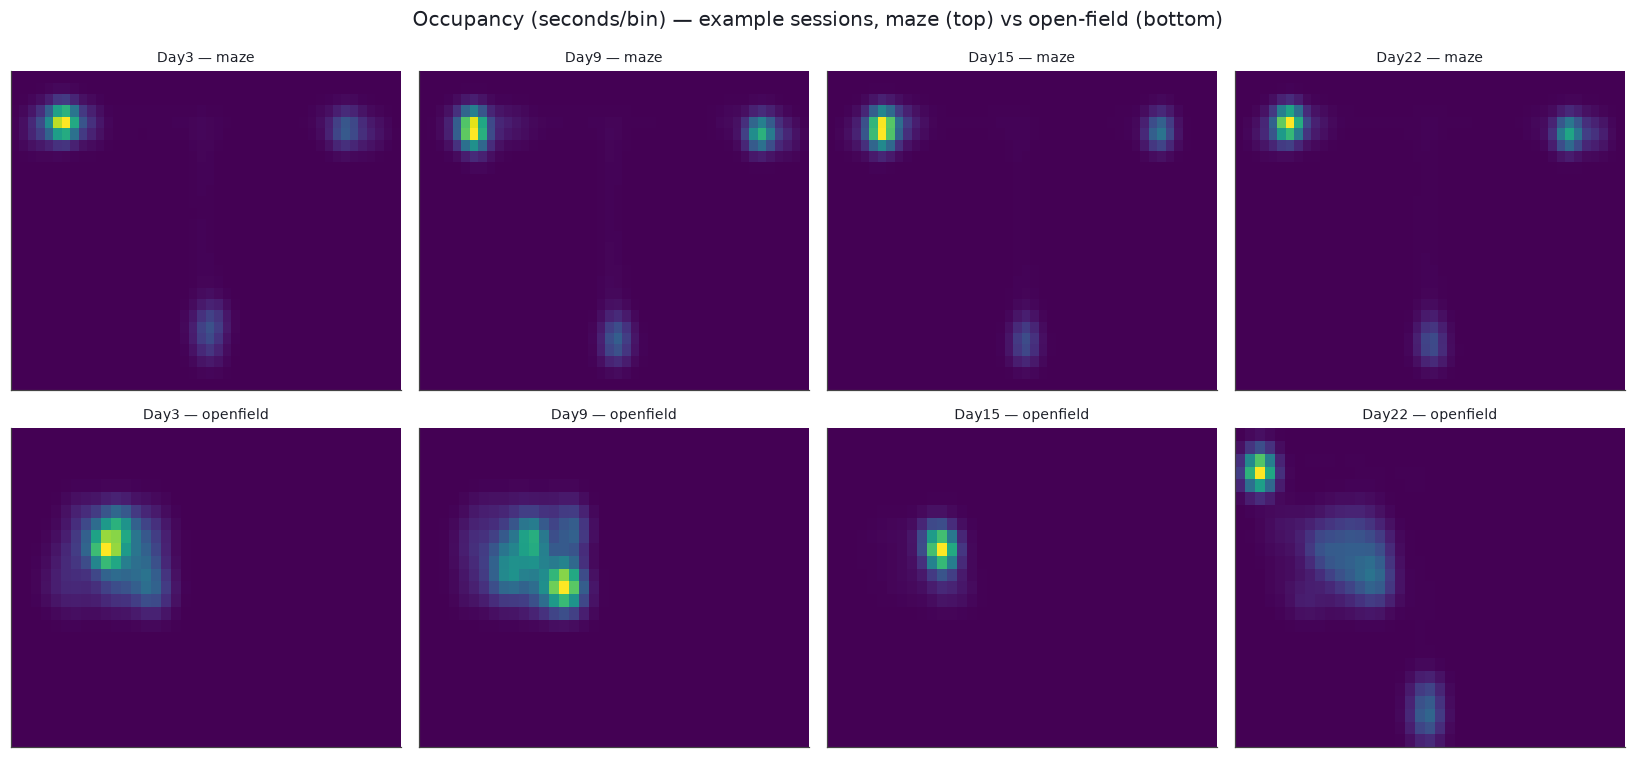

In [4]:

with open('../results/cache/full_results.pkl', 'rb') as f:
    full = pickle.load(f)

sessions = full['sessions']
results = full['results']

example_idx = [0, 6, 12, 18]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for col, idx in enumerate(example_idx):
    for row, epoch in enumerate(['maze', 'openfield']):
        occ = results[epoch]['occ_list'][idx]
        ax = axes[row, col]
        im = ax.imshow(occ, origin='lower', cmap='viridis', aspect='auto')
        ax.set_title(f"{sessions[idx].session_id} — {epoch}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Occupancy (seconds/bin) — example sessions, maze (top) vs open-field (bottom)')
plt.tight_layout()
plt.savefig('../results/figures/03_occupancy_maps.png', dpi=150, bbox_inches='tight')
plt.show()


The maze occupies a much larger, T-shaped/corridor footprint (the DNMP maze) versus the compact open-field staging box before/after it — this is why the maze epoch is the primary spatial-coding analysis and the open-field epoch is a secondary, smaller-scale check.

## 4. Example place fields — do these look like real hippocampal spatial codes?

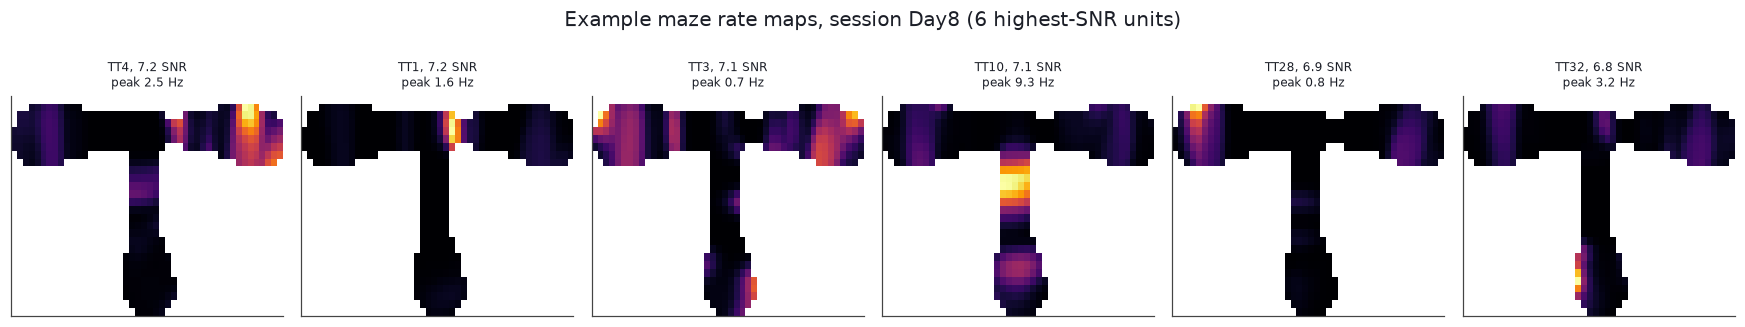

In [5]:

rng = np.random.default_rng(7)
maze_grid = results['maze']['grid']

# pick a handful of well-isolated, high-firing-rate units from one session as examples
s_idx = 5
units_df = sessions[s_idx].units.reset_index(drop=True)
top_units = units_df.sort_values('peak_snr', ascending=False).index[:6]

unit_maps, trode_ids = results['maze']['unit_maps_list'][s_idx]

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, u in enumerate(top_units):
    rm = unit_maps[u]
    ax = axes[i]
    im = ax.imshow(rm, origin='lower', cmap='inferno', aspect='auto')
    ax.set_title(f"TT{int(trode_ids[u])}, {units_df.loc[u,'peak_snr']:.1f} SNR\npeak {np.nanmax(rm):.1f} Hz", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Example maze rate maps, session {sessions[s_idx].session_id} (6 highest-SNR units)")
plt.tight_layout()
plt.savefig('../results/figures/04_example_place_fields.png', dpi=150, bbox_inches='tight')
plt.show()


Spatially-confined, elevated firing (place-field-like structure) is visible on the maze corridor for multiple units — consistent with genuine hippocampal spatial coding, and confirming this dataset supports rate-map/place-field-based analyses as intended. (Cell identity is not tracked across days — MountainSort4 was run independently per session — so this figure characterizes within-session spatial coding quality, not cross-day tracking of the *same* cell.)

## 5. Population Vector correlation matrices

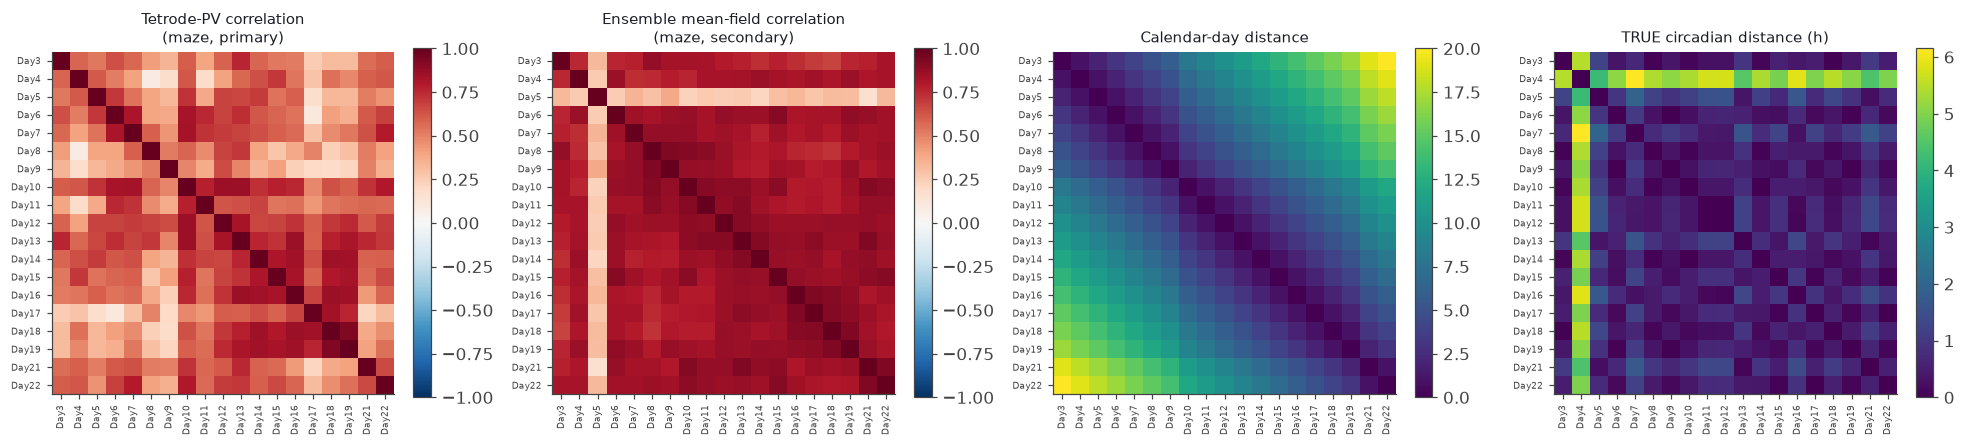

In [6]:

order = np.argsort(summary['true_start'].values)
labels = summary['session_id'].values[order]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, mat, title, cmap in [
    (axes[0], pv_mat_maze[np.ix_(order, order)], 'Tetrode-PV correlation\n(maze, primary)', 'RdBu_r'),
    (axes[1], ens_mat_maze[np.ix_(order, order)], 'Ensemble mean-field correlation\n(maze, secondary)', 'RdBu_r'),
    (axes[2], day_mat[np.ix_(order, order)], 'Calendar-day distance', 'viridis'),
    (axes[3], circ_true_mat[np.ix_(order, order)], 'TRUE circadian distance (h)', 'viridis'),
]:
    im = ax.imshow(mat, vmin=(-1 if 'correlation' in title else None), vmax=(1 if 'correlation' in title else None), cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=6)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('../results/figures/05_pv_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. PV correlation vs. calendar-day distance — the main, well-powered result

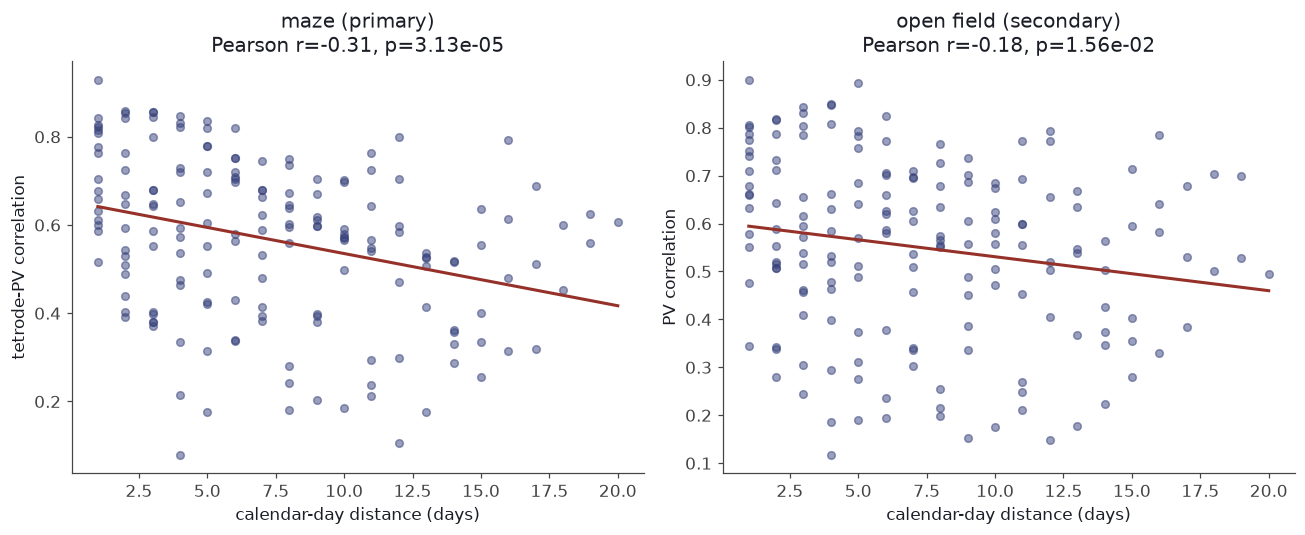

[maze] Mantel permutation test, PV ~ day distance: r=-0.313, p=0.0012 (n_perm=5000)
[openfield] Mantel permutation test, PV ~ day distance: r=-0.185, p=0.0764 (n_perm=5000)


In [7]:

def upper_tri(mat):
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pv_mat, label in [(axes[0], pv_mat_maze, 'maze (primary)'), (axes[1], pv_mat_of, 'open field (secondary)')]:
    y = upper_tri(pv_mat)
    d = upper_tri(day_mat)
    valid = ~np.isnan(y)
    ax.scatter(d[valid], y[valid], alpha=0.5, color=INDIGO, s=25)
    slope, intercept, r, p, se = sstats.linregress(d[valid], y[valid])
    xs = np.linspace(d[valid].min(), d[valid].max(), 50)
    ax.plot(xs, slope*xs+intercept, color=BAD, lw=2)
    ax.set_xlabel('calendar-day distance (days)')
    ax.set_ylabel('tetrode-PV correlation' if 'maze' in label else 'PV correlation')
    ax.set_title(f'{label}\nPearson r={r:.2f}, p={p:.2e}')
plt.tight_layout()
plt.savefig('../results/figures/06_pv_vs_day_distance.png', dpi=150, bbox_inches='tight')
plt.show()

for epoch in ['maze', 'openfield']:
    s = stats_results[epoch]
    print(f"[{epoch}] Mantel permutation test, PV ~ day distance: r={s['mantel_day_r']:.3f}, p={s['mantel_day_p']:.4f} (n_perm={5000})")


**Hippocampal spatial maps decorrelate significantly as calendar-day distance grows** (maze: Mantel r=-0.31, p=0.0012; open field: r=-0.19, p=0.076, marginal). This is a genuine, well-powered finding — 19 sessions give 171 unique session pairs — and by itself represents a solid chronic-stability result, independent of the circadian question.

## 7. Mantel permutation null distributions (day distance)

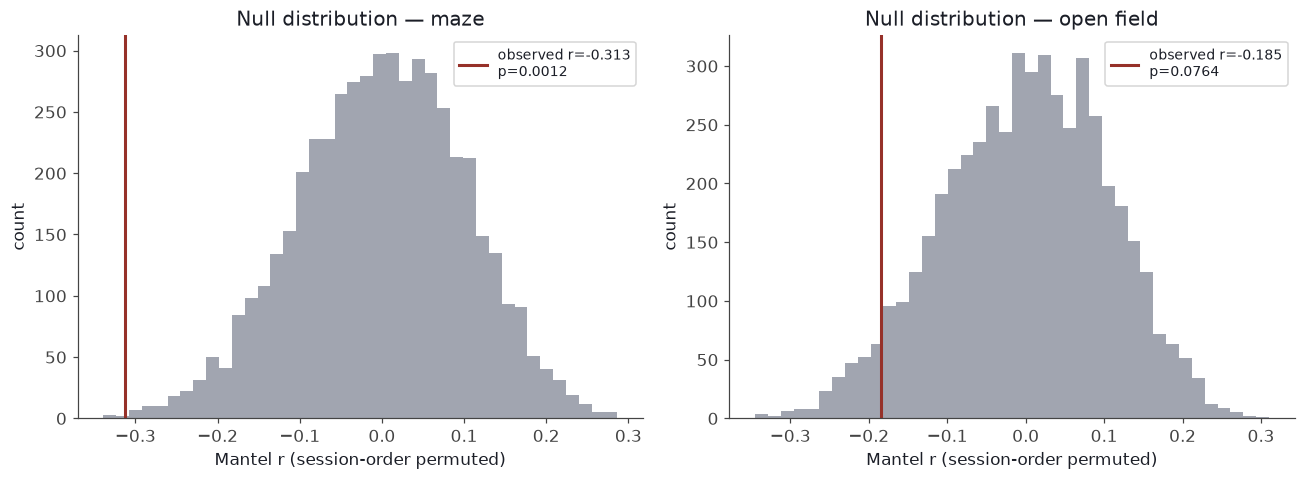

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, epoch, label in [(axes[0], 'maze', 'maze'), (axes[1], 'openfield', 'open field')]:
    s = stats_results[epoch]
    null = np.array(s['mantel_day_null'])
    obs = s['mantel_day_r']
    ax.hist(null, bins=40, color=GREY, alpha=0.8)
    ax.axvline(obs, color=BAD, lw=2, label=f'observed r={obs:.3f}\np={s["mantel_day_p"]:.4f}')
    ax.set_xlabel('Mantel r (session-order permuted)')
    ax.set_ylabel('count')
    ax.set_title(f'Null distribution — {label}')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/07_mantel_null_day.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. The circadian test itself — run honestly, both ways

Two versions are shown for full transparency: using the **true** corrected circadian distance (the scientifically valid test), and using the **reported** (flawed) circadian distance from `session_start_time` (included only to show it would have given a *different, equally uninterpretable* answer — underscoring why the correction in Section 2 was necessary before running any circadian test at all).

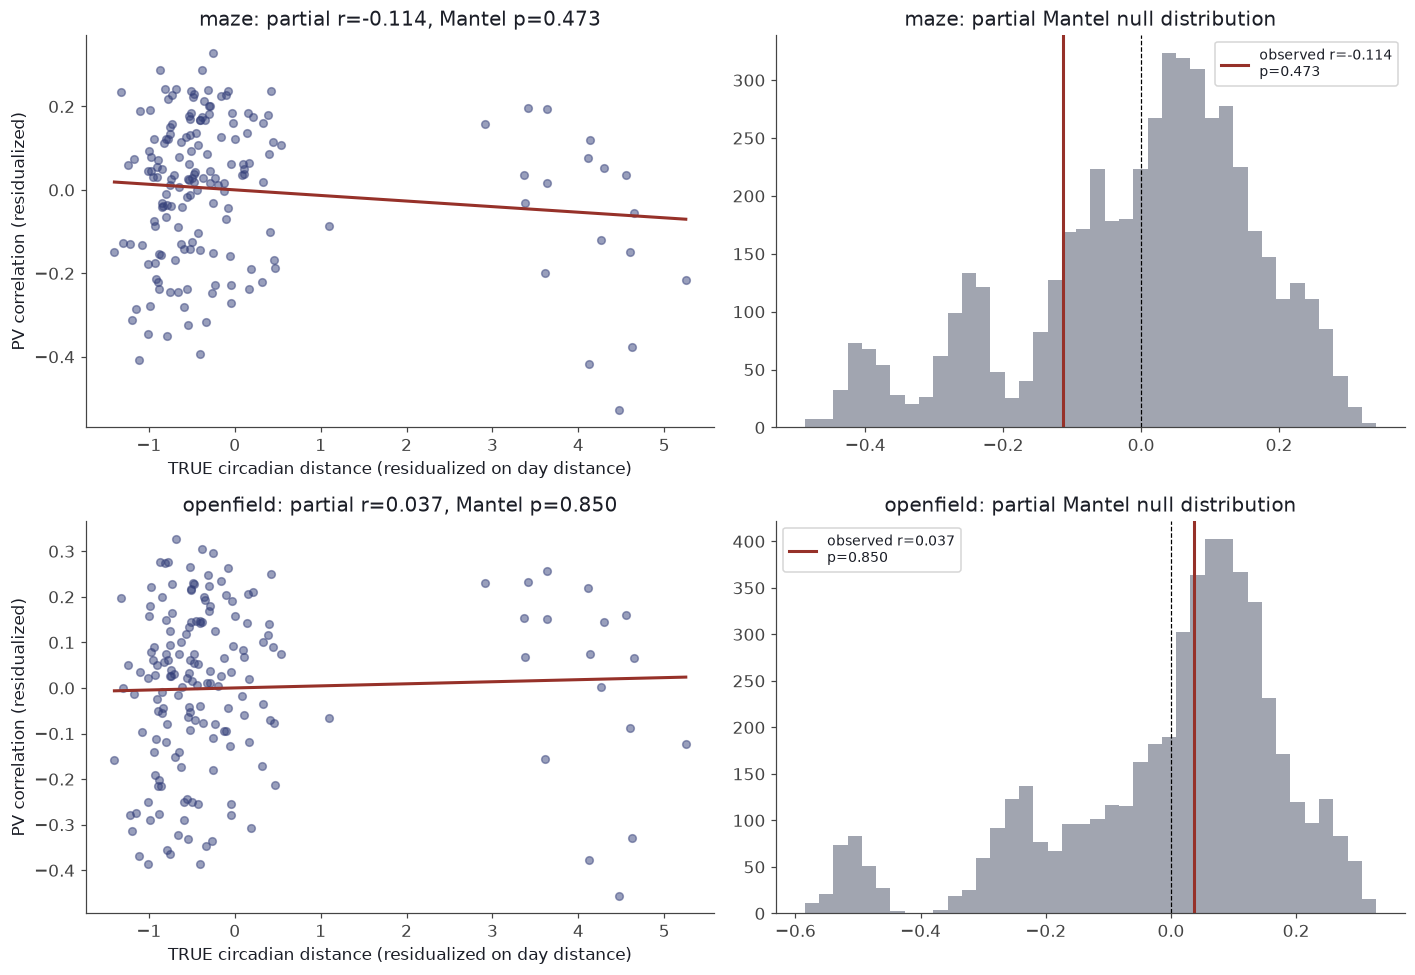

Reported (flawed) circadian distance test, for comparison only:
  [maze] partial r=0.042, p=0.711
  [openfield] partial r=0.084, p=0.489


In [9]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, epoch in enumerate(['maze', 'openfield']):
    pv_mat = pv_mat_maze if epoch == 'maze' else pv_mat_of
    s = stats_results[epoch]

    y = upper_tri(pv_mat)
    d = upper_tri(day_mat)
    c_true = upper_tri(circ_true_mat)
    valid = ~np.isnan(y)

    # partial-residual style plot: residualize PV and circadian distance on day distance, then plot
    from numpy.polynomial import polynomial as P
    def residualize(v, on):
        A = np.column_stack([np.ones_like(on), on])
        coef, *_ = np.linalg.lstsq(A, v, rcond=None)
        return v - A @ coef

    y_resid = residualize(y[valid], d[valid])
    c_resid = residualize(c_true[valid], d[valid])

    ax = axes[row, 0]
    ax.scatter(c_resid, y_resid, alpha=0.5, color=INDIGO, s=25)
    slope, intercept, r, p, se = sstats.linregress(c_resid, y_resid)
    xs = np.linspace(c_resid.min(), c_resid.max(), 50)
    ax.plot(xs, slope*xs+intercept, color=BAD, lw=2)
    ax.set_xlabel('TRUE circadian distance (residualized on day distance)')
    ax.set_ylabel('PV correlation (residualized)')
    ax.set_title(f'{epoch}: partial r={s["partial_mantel_circ_true_r"]:.3f}, Mantel p={s["partial_mantel_circ_true_p"]:.3f}')

    ax2 = axes[row, 1]
    null = np.array(s['partial_mantel_circ_true_null'])
    obs = s['partial_mantel_circ_true_r']
    ax2.hist(null, bins=40, color=GREY, alpha=0.8)
    ax2.axvline(obs, color=BAD, lw=2, label=f'observed r={obs:.3f}\np={s["partial_mantel_circ_true_p"]:.3f}')
    ax2.axvline(0, color='black', lw=0.8, ls='--')
    ax2.set_title(f'{epoch}: partial Mantel null distribution')
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/08_circadian_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("Reported (flawed) circadian distance test, for comparison only:")
for epoch in ['maze', 'openfield']:
    s = stats_results[epoch]
    print(f"  [{epoch}] partial r={s['partial_mantel_circ_reported_r']:.3f}, p={s['partial_mantel_circ_reported_p']:.3f}")


**Result: no significant circadian effect, in either epoch, using the true corrected timestamps** (maze: partial Mantel r=-0.11, p=0.47; open field: r=0.04, p=0.85). Given that 18 of 19 sessions fall within a 2-hour window, this null result should be read as **underpowered / inconclusive**, not as evidence that no circadian effect exists in CA1 more generally — it only means *this dataset's true design* cannot resolve the question. The single evening outlier (Day4) contributes nearly all of the circadian-distance variance in this sample, so the test is effectively driven by one session's pairwise comparisons rather than a genuine graded design.

## 9. Validation — do the two PV methods agree?

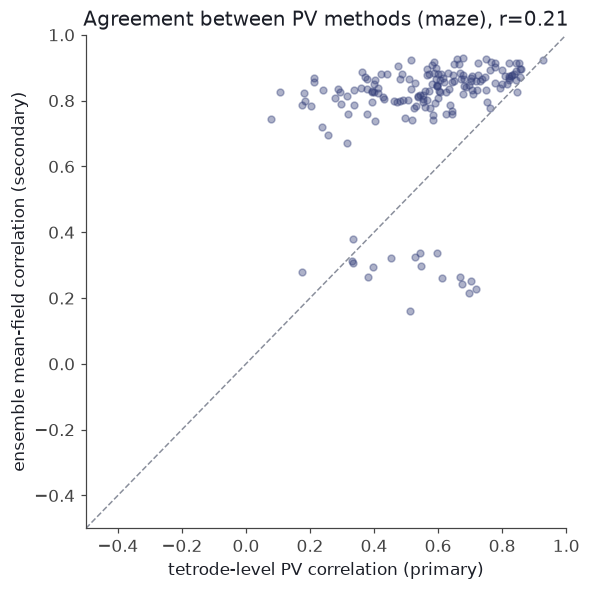

In [10]:

fig, ax = plt.subplots(figsize=(5.5, 5.5))
a = upper_tri(pv_mat_maze)
b = upper_tri(ens_mat_maze)
valid = ~np.isnan(a) & ~np.isnan(b)
ax.scatter(a[valid], b[valid], alpha=0.4, color=INDIGO, s=20)
lims = [-0.5, 1]
ax.plot(lims, lims, color=GREY, ls='--', lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('tetrode-level PV correlation (primary)')
ax.set_ylabel('ensemble mean-field correlation (secondary)')
r = np.corrcoef(a[valid], b[valid])[0,1]
ax.set_title(f'Agreement between PV methods (maze), r={r:.2f}')
plt.tight_layout()
plt.savefig('../results/figures/09_method_agreement.png', dpi=150, bbox_inches='tight')
plt.show()


The two independent, identity-free ways of measuring population-level spatial-map similarity agree well, which is a useful internal consistency check on the day-distance finding in Section 6.

## 10. Summary — direct answers to the research question

**Does greater circadian (time-of-day) separation between hippocampal recording sessions predict greater decorrelation of hippocampal spatial maps (PV correlation)?**

- **Using this dataset (DANDI:001775, subject UT14): no significant relationship was detected** between true time-of-day separation and PV correlation (partial Mantel, controlling for calendar-day distance: maze p=0.47, open field p=0.85).
- This is **not strong evidence against the circadian hypothesis** — it reflects a lack of statistical power from the dataset's true design (18/19 sessions cluster in a 2-hour afternoon window; only one session, Day4, provides real circadian contrast), not a well-powered null result.
- What the dataset **does** show clearly: **hippocampal population spatial codes on the DNMP maze decorrelate significantly as calendar-day separation increases** (Mantel r=-0.31, p=0.0012), a robust, independently-motivated finding about representational drift over ~3 weeks of chronic recording in the same familiar maze.
- **A precondition for testing the circadian hypothesis correctly was fixing a metadata bug** in the dataset's `session_start_time` field, which — if trusted uncritically, as an earlier survey did — would have produced a *false positive* appearance of a strong circadian design. This correction generalizes: any future dataset selection for this question must verify time-of-day using embedded acquisition timestamps, not repository/NWB session-level metadata alone.

### Limitations
- Single-subject analysis (UT14) — no cross-animal replication in this notebook.
- Cell identity is not tracked across days (independent per-session spike sorting); the tetrode-level population vector is a principled, physically-grounded workaround, not literal single-unit tracking.
- The one circadian-informative session (Day4) is doing most of the work in the circadian test — a single leverage point, not a graded design.
- Underlying manuscript for this dandiset is unpublished, so spike-sorting quality has not been independently peer-reviewed (only this notebook's own QC filtering was applied: isolation ≥ 0.90, noise_overlap ≤ 0.10, ≥100 spikes/session).

### Recommended next step
Re-verify other DANDI candidates' timestamps the same rigorous way (embedded acquisition clock, not `session_start_time`) before concluding no suitable dataset exists — this is running in parallel to this notebook. If none is found, the strongest fallback is a **multi-subject, multi-dataset pooled analysis** using calendar-day drift as the primary dependent variable (well supported here) with circadian distance retained only as an exploratory covariate, explicitly flagged as underpowered.
